# Verification Notebook 5
# Multi-Model Switching with Contact

In [3]:
from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

In [4]:
import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display
from plot_setup import set_professional_style, FULL_WIDTH
plt = set_professional_style(latex=True)

from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config
from syssimx import FMUComponent, System, Connection, EventConnection


## Discover FMUs

In [5]:
PLATFORM = sys.platform
demo_dir_path = _repo / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir


## Modelica Reference Simulation

In [6]:
from OMPython import ModelicaSystem

reference = ModelicaSystem(fileName=str(package_path / "package.mo"),
                           modelName="ControlledPendulum.Examples.Contact.RigidContact")
reference.setParameters({'useReset':'true'})
reference.buildModel()
reference.simulate()
ref_sol_names = ('time', 'theta', 'theta_ref', 'theta_meas', 'u_control', 'pid.I_out', 'pendulum.contact')
ref_sol_reset = {name: reference.getSolutions(name).flatten() for name in ref_sol_names}

[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").
[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


## Instantiate FMU Components

In [7]:
def print_parameteres(component: FMUComponent):
    print(f"Parameters of {component.name}:")
    for name, param in component.parameters.items():
        if '.' not in name and param is not None:
            print(f"  - {name}: {param}")

## Components

In [8]:
setpoint = FMUComponent(name="Setpoint",
                         fmu_path=fmu_paths['Trajectories']["SetPoint"],
                         group="Reference")

class PIDController(FMUComponent):
    def __init__(self, name):
        fmu_path = fmu_paths['Controllers']['PIDControllerReset_euler']
        super().__init__(name=name, fmu_path=fmu_path, group="Controller")

    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        self.set_inputs({"resetI": True})
        self.do_step(t, 0)  # Perform a step to apply the resetI input
        self.set_inputs({"resetI": False})

pid = PIDController(name="PID")

drive = FMUComponent(name="Drive",
                     fmu_path=fmu_paths['Actuators']["DriveDynamic"],
                     group="Actuator")

sim_params = config.SimulationParameters()
sim_params.tau = 0.001
sim_params.t_end = 0.4
sim_params.with_contact = True
sim_params.use_gravity = True

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'sim_params': sim_params,
    'anim_params': anim_params,
}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")
pendulum.record_switch_state = True
pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)

def wall_contact_indicator(comp: MasterPendulum) -> float:
    theta = comp.get_outputs()["theta"]
    theta_wall = 0.0
    theta = theta.magnitude if hasattr(theta, "magnitude") else theta
    return float(theta) - theta_wall

pendulum.add_event_indicator("wall_hit", func=wall_contact_indicator, direction=-1)

angle_sensor = FMUComponent(name="Angle Sensor",
                             fmu_path=fmu_paths['Sensors']['AngleSensor'],
                             group="Sensors")

angle_decoder = FMUComponent(name="Angle Decoder",
                             fmu_path=fmu_paths['Sensors']['AngleDecoder'],
                             group="Signal Processing")


## Connections

In [9]:
c1 = Connection(
    src_comp=setpoint.name,
    src_port=setpoint.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c21 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=angle_sensor.name,
    dst_port=angle_sensor.input_specs["theta"].name,
)

c22 = Connection(
    src_comp=angle_sensor.name,
    src_port=angle_sensor.output_specs["v_out"].name,
    dst_comp=angle_decoder.name,
    dst_port=angle_decoder.input_specs["v_in"].name,
)

c23 = Connection(
    src_comp=angle_decoder.name,
    src_port=angle_decoder.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c3 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c4 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c5 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

event_connection_1 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["omega_invert"].name,
)

event_connection_2 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pid.name,
    dst_port=pid.input_specs["resetI"].name,
)

connections = [c1, c21, c22, c23, c3, c4, c5]
components  = [setpoint, pid, drive, pendulum, angle_decoder, angle_sensor]

system = System(name="Pendulum System with Master Pendulum")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.add_event_connection(event_connection_1)
system.add_event_connection(event_connection_2)

system.initialize(t0=0.0)

In [10]:
system.algorithm.record_internal_steps = False
system.algorithm.event_dedup_tol = 5e-4
system.algorithm.tol_time = 1e-5
system.algorithm.tol_value = 5e-5

## Run Simulation

In [11]:
t = 0.0
dt = sim_params.tau
t_end = sim_params.t_end

# The declared initial_mode is only a request. Initialization reconciles the
# region from the initialized switching signal, and that reconciliation is not
# recorded in sync_events, so the mode that actually starts the run has to be
# read back here. With theta0 = 0 the wrapper starts inside the FEM region.
initial_mode = pendulum.active_mode
print("declared initial mode : FMU")
print(f"reconciled region     : {pendulum.active_region_index} ({initial_mode})")

system.run(t, t_end, dt)


declared initial mode : FMU
reconciled region     : 0 (FEM)


<SimulationResult 'Pendulum System with Master Pendulum' t=[0.0, 0.4] dt=0.001 components=6 algorithm=HybridAlgorithm>

In [12]:
# system_res_file = _repo / "demos/ControlledPendulum/artifacts/results/master_pendulum_system.csv"
# system_res_file.parent.mkdir(parents=True, exist_ok=True)
# system.history.save_csv(filepath=system_res_file)

## Collect Results

In [13]:
history = system.get_history()
fem_hist = pendulum.fem.get_history()
fmu_hist = pendulum.fmu.get_history()
opensim_hist = pendulum.opensim.get_history()

ref_history = history["Setpoint"]
setpoint_time, data = ref_history
theta_ref = data["theta_ref"]

t_fem = fem_hist['theta']['time']
theta_fem = fem_hist['theta']['values']
t_fmu = fmu_hist['theta']['time']
theta_fmu = fmu_hist['theta']['values']
t_opensim = opensim_hist['theta']['time']
theta_opensim = opensim_hist['theta']['values']

t_pid = history["PID"][0]
i_out = history["PID"][1]['I_out']
u_pid = history["PID"][1]['u']

event_history = history['Events']
event_times_dense = event_history[('MasterPendulum', 'wall_hit')]
event_times_float = [dense.t for dense in event_times_dense]

# Reference contact instants are the rising edges of the Modelica contact flag,
# not every second sample of it: the flag stays high for the whole contact
# phase, so a fixed stride silently mislabels the events it pairs up.
contact_flag = np.asarray(ref_sol_reset['pendulum.contact']) > 0
rising_edges = np.flatnonzero(np.diff(contact_flag.astype(int)) == 1) + 1
event_times_ref = ref_sol_reset['time'][rising_edges]
event_times_ref = event_times_ref[event_times_ref <= t_end]

# Pair only what both sides resolved; an unequal count is a physics difference
# and has to be visible rather than raising a shape error here.
n_events_compared = min(len(event_times_float), len(event_times_ref))
diff_event_times = (
    np.asarray(event_times_float[:n_events_compared], dtype=float)
    - np.asarray(event_times_ref[:n_events_compared], dtype=float)
)

print(f"contact events: syssimx {len(event_times_float)}, "
      f"Modelica {len(event_times_ref)}, compared {n_events_compared}")
if len(event_times_float) != len(event_times_ref):
    print("WARNING: the two runs resolved different contact sequences. "
          "The event-time deltas below pair events that may not correspond.")


contact events: syssimx 5, Modelica 5, compared 5


In [14]:
def trajectory_error_metrics(t, y, t_ref, y_ref, *, t_min=None, t_max=None):
    """Compute sampled trajectory errors against an interpolated reference."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    t_ref = np.asarray(t_ref, dtype=float)
    y_ref = np.asarray(y_ref, dtype=float)

    mask = np.ones_like(t, dtype=bool)
    if t_min is not None:
        mask &= t >= t_min
    if t_max is not None:
        mask &= t <= t_max

    t_eval = t[mask]
    y_eval = y[mask]
    y_ref_eval = np.interp(t_eval, t_ref, y_ref)

    err = y_eval - y_ref_eval
    duration = t_eval[-1] - t_eval[0]

    return {
        "e_inf": np.max(np.abs(err)),
        "e_2": np.sqrt(np.trapezoid(err**2, t_eval) / duration),
        "e_mean": np.mean(np.abs(err)),
        "n_samples": len(t_eval),
    }


def event_time_metrics(t_events, t_events_ref):
    """Compare event times pairwise."""
    t_events = np.asarray(t_events, dtype=float)
    t_events_ref = np.asarray(t_events_ref, dtype=float)

    n = min(len(t_events), len(t_events_ref))
    delta = t_events[:n] - t_events_ref[:n]

    return {
        "n_syssimx": len(t_events),
        "n_reference": len(t_events_ref),
        "n_compared": n,
        "max_abs_delta": np.max(np.abs(delta)) if n else np.nan,
        "mean_abs_delta": np.mean(np.abs(delta)) if n else np.nan,
        "delta": delta,
    }


# Main switched plant output.
t_master, data_master = history["MasterPendulum"]
theta_master = np.asarray(data_master["theta"], dtype=float)

# Optional diagnostic signal.
t_pid = np.asarray(t_pid, dtype=float)
i_out = np.asarray(i_out, dtype=float)

# Full horizon errors.
theta_metrics_full = trajectory_error_metrics(
    t_master,
    theta_master,
    ref_sol_reset["time"],
    ref_sol_reset["theta"],
)

pid_metrics_full = trajectory_error_metrics(
    t_pid,
    i_out,
    ref_sol_reset["time"],
    ref_sol_reset["pid.I_out"],
)

# Contact-window errors.
# Use a slightly wider interval than the plotted contact window.
contact_window = (0.15, 0.35)

theta_metrics_contact = trajectory_error_metrics(
    t_master,
    theta_master,
    ref_sol_reset["time"],
    ref_sol_reset["theta"],
    t_min=contact_window[0],
    t_max=contact_window[1],
)

pid_metrics_contact = trajectory_error_metrics(
    t_pid,
    i_out,
    ref_sol_reset["time"],
    ref_sol_reset["pid.I_out"],
    t_min=contact_window[0],
    t_max=contact_window[1],
)

u_metrics_full = trajectory_error_metrics(
    t_pid, u_pid, ref_sol_reset["time"], ref_sol_reset["u_control"])
u_metrics_contact = trajectory_error_metrics(
    t_pid, u_pid, ref_sol_reset["time"], ref_sol_reset["u_control"],
    t_min=contact_window[0], t_max=contact_window[1])


event_metrics = event_time_metrics(event_times_float, event_times_ref)

df_metrics = pd.DataFrame(
    [
        {
            "Quantity": r"$\theta$ full horizon",
            **theta_metrics_full,
        },
        {
            "Quantity": r"$\theta$ contact window",
            **theta_metrics_contact,
        },
        {
            "Quantity": r"$I_{\mathrm{out}}$ full horizon",
            **pid_metrics_full,
        },
        {
            "Quantity": r"$I_{\mathrm{out}}$ contact window",
            **pid_metrics_contact,
        },
        {
            "Quantity": r"$u_{\mathrm{control}}$ full horizon",
            **u_metrics_full,
        },
        {
            "Quantity": r"$u_{\mathrm{control}}$ contact window",
            **u_metrics_contact,
        },
    ]
)

df_metrics


,Quantity,e_inf,e_2,e_mean,n_samples
0,$\theta$ full horizon,0.023647,0.005803,0.003732,426
1,$\theta$ contact window,0.023647,0.008031,0.006186,213
2,$I_{\mathrm{out}}$ full horizon,0.112052,0.009475,0.003294,424
3,$I_{\mathrm{out}}$ contact window,0.112052,0.013317,0.005140,217
4,$u_{\mathrm{control}}$ full horizon,0.196129,0.036555,0.012562,424
5,$u_{\mathrm{control}}$ contact window,0.196129,0.045363,0.015171,217


In [15]:
df_metrics_clean = pd.DataFrame(
    [
        {
            "Signal": "theta",
            "Interval": "full horizon",
            "E_inf": theta_metrics_full["e_inf"],
            "E_2": theta_metrics_full["e_2"],
            "E_mean": theta_metrics_full["e_mean"],
        },
        {
            "Signal": "theta",
            "Interval": "contact window",
            "E_inf": theta_metrics_contact["e_inf"],
            "E_2": theta_metrics_contact["e_2"],
            "E_mean": theta_metrics_contact["e_mean"],
        },
        {
            "Signal": "I_out",
            "Interval": "full horizon",
            "E_inf": pid_metrics_full["e_inf"],
            "E_2": pid_metrics_full["e_2"],
            "E_mean": pid_metrics_full["e_mean"],
        },
        {
            "Signal": "I_out",
            "Interval": "contact window",
            "E_inf": pid_metrics_contact["e_inf"],
            "E_2": pid_metrics_contact["e_2"],
            "E_mean": pid_metrics_contact["e_mean"],
        },
        {
            "Signal": "u_control",
            "Interval": "full horizon",
            "E_inf": u_metrics_full["e_inf"],
            "E_2": u_metrics_full["e_2"],
            "E_mean": u_metrics_full["e_mean"],
        },
        {
            "Signal": "u_control",
            "Interval": "contact window",
            "E_inf": u_metrics_contact["e_inf"],
            "E_2": u_metrics_contact["e_2"],
            "E_mean": u_metrics_contact["e_mean"],
        },
    ]
)

display(
    df_metrics_clean.style
    .format({"E_inf": "{:.3e}", "E_2": "{:.3e}", "E_mean": "{:.3e}"})
    .hide(axis="index")
)


Signal,Interval,E_inf,E_2,E_mean
theta,full horizon,2.365e-02,5.803e-03,3.732e-03
theta,contact window,2.365e-02,8.031e-03,6.186e-03
I_out,full horizon,1.121e-01,9.475e-03,3.294e-03
I_out,contact window,1.121e-01,1.332e-02,5.140e-03
u_control,full horizon,1.961e-01,3.656e-02,1.256e-02
u_control,contact window,1.961e-01,4.536e-02,1.517e-02


In [16]:
df_metrics_latex = df_metrics_clean.copy()
df_metrics_latex = df_metrics_latex.rename(
    columns={
        "E_inf": r"$E_\infty$",
        "E_2": r"$E_2$",
        "E_mean": r"$E_\mathrm{mean}$",
    }
)

print(
    df_metrics_latex.to_latex(
        index=False,
        escape=False,
        float_format="{:.3e}".format,
    )
)


\begin{tabular}{llrrr}
\toprule
Signal & Interval & $E_\infty$ & $E_2$ & $E_\mathrm{mean}$ \\
\midrule
theta & full horizon & 2.365e-02 & 5.803e-03 & 3.732e-03 \\
theta & contact window & 2.365e-02 & 8.031e-03 & 6.186e-03 \\
I_out & full horizon & 1.121e-01 & 9.475e-03 & 3.294e-03 \\
I_out & contact window & 1.121e-01 & 1.332e-02 & 5.140e-03 \\
u_control & full horizon & 1.961e-01 & 3.656e-02 & 1.256e-02 \\
u_control & contact window & 1.961e-01 & 4.536e-02 & 1.517e-02 \\
\bottomrule
\end{tabular}



In [17]:
df_events = pd.DataFrame({
    "syssimx (s)": event_times_float[:n_events_compared],
    "Modelica (s)": event_times_ref[:n_events_compared],
    "Delta (s)": diff_event_times,
})
df_events.index.name = "Event"
df_events.style.format("{:.6f}")


,syssimx (s),Modelica (s),Delta (s)
Event,,,
0,0.172544,0.172112,0.000432
1,0.211688,0.211092,0.000596
2,0.251094,0.250071,0.001023
3,0.290850,0.289050,0.001800
4,0.331363,0.328029,0.003333


In [18]:
print(f"E_inf theta full      = {theta_metrics_full['e_inf']:.3e} rad")
print(f"E_2 theta full        = {theta_metrics_full['e_2']:.3e} rad")
print(f"E_inf theta contact   = {theta_metrics_contact['e_inf']:.3e} rad")
print(f"E_2 theta contact     = {theta_metrics_contact['e_2']:.3e} rad")
print(f"max event time error  = {event_metrics['max_abs_delta']:.3e} s")


E_inf theta full      = 2.365e-02 rad
E_2 theta full        = 5.803e-03 rad
E_inf theta contact   = 2.365e-02 rad
E_2 theta contact     = 8.031e-03 rad
max event time error  = 3.333e-03 s


In [19]:
def build_mode_intervals(sync_events, initial_mode, t0, tf):
    rows = []
    current_mode = initial_mode
    current_t = t0

    for event in sync_events:
        switch_t = event["time"]
        rows.append((current_t, switch_t, current_mode))
        current_t = switch_t
        current_mode = event["to_mode"]

    rows.append((current_t, tf, current_mode))
    return rows

# initial_mode is the reconciled mode read back before the run, not the mode
# requested at construction.
mode_intervals = build_mode_intervals(
    pendulum.sync_events,
    initial_mode=initial_mode,
    t0=0.0,
    tf=t_end,
)


## Plot: Multi-Model Switching
This plot overlays all three sub-models and the setpoint.

In [20]:
marker_size = 2
palette = {
    "fem": "#1f77b4",
    "opensim": "#ff7f0e",
    "fmu": "#2ca02c",
    "setpoint": "#d62728",
}

fem_style = {
    "color": palette["fem"],
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 2.5,
}
opensim_style = {
    "color": palette["opensim"],
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 2.5,
}
fmu_style = {
    "color": palette["fmu"],
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 2.5,
}

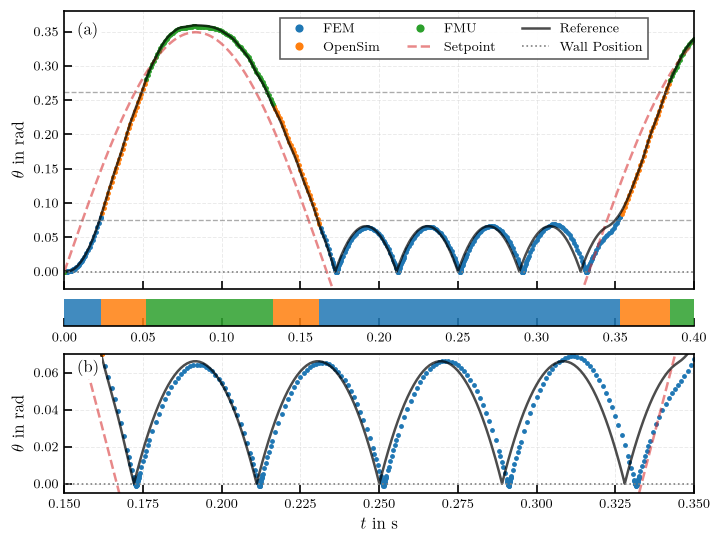

In [21]:
fig = plt.figure(figsize=(FULL_WIDTH, 0.75 * FULL_WIDTH), constrained_layout=True)
gs = fig.add_gridspec(3, 1, height_ratios=[4, 0.4, 2])
ax_full = fig.add_subplot(gs[0, 0])
ax_mode = fig.add_subplot(gs[1, 0], sharex=ax_full)
ax_contact = fig.add_subplot(gs[2, 0])

for ax in (ax_full, ax_contact):
    ax.plot(t_fem, theta_fem, label="FEM", **fem_style)
    ax.plot(t_opensim, theta_opensim, label="OpenSim", **opensim_style)
    ax.plot(t_fmu, theta_fmu, label="FMU", **fmu_style)
    ax.plot(setpoint_time, theta_ref, label="Setpoint", color=palette["setpoint"], linestyle="--", linewidth=1.5, alpha=0.55)
    ax.plot(ref_sol_reset['time'], ref_sol_reset['theta'], 'k-', label="Reference", markersize=1, linewidth=1.5, alpha=0.7)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1, label="Wall Position")
    for threshold in pendulum.switch_regions.breakpoints:
        ax.axhline(threshold, color="0.45", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel(r"$\theta$ in $\mathrm{rad}$")

ax_full.set_ylim(-0.025, 0.38)
ax_full.tick_params(labelbottom=False)
ax_full.legend(loc="upper center", bbox_to_anchor=(0.635, 1), ncol=3, markerscale=2, fontsize=8)
ax_contact.set_xlabel(r"$t$ in $\mathrm{s}$")

ax_contact.set_xlim(0.15, 0.35)
ax_contact.set_ylim(-0.005, 0.07)

for t0_i, t1_i, mode in mode_intervals:
    ax_mode.broken_barh(
        [(t0_i, t1_i - t0_i)],
        (0, 1),
        facecolors=palette[mode.lower()],
        edgecolors="none",
        alpha=0.85,
    )

ax_mode.set_ylim(0, 1)
ax_mode.set_xlim(0, t_end)
ax_mode.set_yticks([])
ax_mode.grid(False)

for spine in ["left", "right", "top"]:
    ax_mode.spines[spine].set_visible(False)

for label, ax in [("(a)", ax_full), ("(b)", ax_contact)]:
    ax.text(0.02, 0.96,
        label, transform=ax.transAxes,
        ha="left", va="top",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=1, pad=1.5),
    )

out = _repo / "notebooks" / "figures"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "05_a_multi_model_switching.pdf")
plt.show()


### Model Switching and Synchronicity

Each committed transfer carries a `PendulumTransferReport`. Two groups of quantities have to be read
differently.

`theta`, `omega`, and `tau` are *enforced* invariants. `MasterPendulum._build_transfer_report`
raises and rolls the transaction back when any of them jumps further than the configured tolerance,
so a completed run cannot show a violation of them. Their columns below confirm the transaction
contract held; they are not a measurement of switching quality.

`alpha` and the energy terms are *measured but not enforced*, because the canonical interface
carries angular position, velocity, and torque only. They are the quantities that actually price a
handover. `elastic_lost` is the strain energy present in the FEM state and absent from the rigid
target, which is the projection loss of leaving the deformable model.


In [22]:
switch_rows = []
for event in pendulum.sync_events:
    report = event["transfer_report"]
    semantics = report.semantics
    switch_rows.append({
        "t": event["time"],
        "from": event["from_mode"],
        "to": event["to_mode"],
        # Enforced by the transaction: these cannot exceed the tolerances.
        "d_theta": report.theta_error,
        "d_omega": report.omega_error,
        "d_tau": report.tau_error,
        # Measured only: the real cost of the handover.
        "d_alpha": report.alpha_error,
        "d_energy": report.energy_error,
        "elastic_lost": report.elastic_energy_lost,
        "d_energy_total": report.total_energy_error,
        "lost_canonical": ", ".join(
            name for name in semantics.lost if name in ("theta", "omega", "alpha", "tau")
        ) or "-",
        "violations": ", ".join(report.violations(pendulum.transfer_tolerances)) or "-",
    })

df_switching = pd.DataFrame(switch_rows)

display(
    df_switching.style
    .format({
        "t": "{:.6f}",
        "d_theta": "{:.3e}",
        "d_omega": "{:.3e}",
        "d_tau": "{:.3e}",
        "d_alpha": "{:.3e}",
        "d_energy": "{:.3e}",
        "elastic_lost": "{:.3e}",
        "d_energy_total": "{:.3e}",
    })
    .hide(axis="index")
)


t,from,to,d_theta,d_omega,d_tau,d_alpha,d_energy,elastic_lost,d_energy_total,lost_canonical,violations
0.023250,FEM,OpenSim,0.000e+00,0.000e+00,0.000e+00,4.882e-06,0.000e+00,1.056e-05,1.056e-05,alpha,-
0.051844,OpenSim,FMU,0.000e+00,0.000e+00,0.000e+00,5.684e-14,0.000e+00,0.000e+00,0.000e+00,alpha,-
0.132469,FMU,OpenSim,0.000e+00,0.000e+00,0.000e+00,1.137e-13,0.000e+00,0.000e+00,0.000e+00,alpha,-
0.162047,OpenSim,FEM,1.804e-16,3.553e-15,1.776e-15,3.411e-13,1.110e-15,-6.642e-19,1.110e-15,alpha,-
0.353109,FEM,OpenSim,0.000e+00,0.000e+00,0.000e+00,3.082e-04,0.000e+00,2.260e-05,2.260e-05,alpha,-
0.384945,OpenSim,FMU,0.000e+00,0.000e+00,0.000e+00,5.684e-14,0.000e+00,0.000e+00,0.000e+00,alpha,-


In [23]:
switch_summary = {
    "n_switches": len(df_switching),
    "tol_theta": pendulum.transfer_tolerances.theta,
    "tol_omega": pendulum.transfer_tolerances.omega,
    "tol_tau": pendulum.transfer_tolerances.tau,
    "max_d_theta": df_switching["d_theta"].max(),
    "max_d_omega": df_switching["d_omega"].max(),
    "max_d_tau": df_switching["d_tau"].max(),
    "max_d_alpha": df_switching["d_alpha"].max(),
    "max_d_energy": df_switching["d_energy"].max(),
    "max_elastic_lost": df_switching["elastic_lost"].max(),
    "any_violation": bool((df_switching["violations"] != "-").any()),
}

switch_summary


{'n_switches': 6,
 'tol_theta': 1e-08,
 'tol_omega': 1e-08,
 'tol_tau': 1e-10,
 'max_d_theta': np.float64(1.8041124150158794e-16),
 'max_d_omega': np.float64(3.552713678800501e-15),
 'max_d_tau': np.float64(1.7763568394002505e-15),
 'max_d_alpha': np.float64(0.00030821457875163105),
 'max_d_energy': np.float64(1.1102230246251565e-15),
 'max_elastic_lost': np.float64(2.2596410100236774e-05),
 'any_violation': False}

### Boundary Localization

`set_switch_regions()` generates one bidirectional indicator per physical boundary, named
`region_boundary_i`, and the hybrid algorithm localizes each crossing by bisection. Those events are
recorded in the system event history alongside `wall_hit`, so the placement of every region change
can be read directly rather than inferred from the switch log.

Each boundary is a Schmitt trigger: the indicator is armed at the far edge of its hysteresis band,
so a located crossing sits on `breakpoint + band` when the key rises and on `breakpoint - band` when
it falls, never on the breakpoint itself. `armed` is that active threshold and `residual` is the
distance of the key from it at the located instant, which shows how tightly the crossing was
resolved. Measuring against the nominal breakpoint instead would report the band width and say
nothing about localization.

`off_grid` is the distance from the located instant to the nearest communication point. It shows
that the transition is placed independently of the macro grid: a value near zero would mean the
switch merely landed on a step boundary.


In [24]:
t_master, data_master = history["MasterPendulum"]
t_master = np.asarray(t_master, dtype=float)
abs_theta_master = np.abs(np.asarray(data_master["theta"], dtype=float))

boundaries = pendulum.switch_regions.boundaries


def _distance_to_grid(t_value, step):
    """Distance from t_value to the nearest communication point."""
    remainder = t_value % step
    return min(remainder, step - remainder)


boundary_rows = []
for (comp_name, event_name), records in event_history.items():
    if not event_name.startswith("region_boundary_"):
        continue
    boundary = boundaries[int(event_name.rsplit("_", 1)[1])]
    for record in records:
        t_event = float(record.t)
        # The located instant is an accepted communication point of the run, so
        # interpolating the recorded trajectory reproduces the key there.
        key_value = float(np.interp(t_event, t_master, abs_theta_master))
        # Which band edge was armed follows from the side the key ended up on.
        armed = (
            boundary.upper_threshold
            if key_value >= boundary.breakpoint
            else boundary.lower_threshold
        )
        committed = [e for e in pendulum.sync_events if abs(e["time"] - t_event) <= 1e-12]
        boundary_rows.append({
            "t": t_event,
            "boundary": event_name,
            "breakpoint": boundary.breakpoint,
            "band": boundary.band,
            "armed": armed,
            "key": key_value,
            "residual": key_value - armed,
            "off_grid": _distance_to_grid(t_event, dt),
            "switch": f"{committed[0]['from_mode']} -> {committed[0]['to_mode']}" if committed else "-",
        })

df_boundaries = pd.DataFrame(boundary_rows).sort_values("t").reset_index(drop=True)

if df_boundaries.empty:
    print("No region boundary crossings were localized in this run.")
else:
    display(
        df_boundaries.style
        .format({
            "t": "{:.6f}",
            "breakpoint": "{:.4f}",
            "band": "{:.4f}",
            "armed": "{:.6f}",
            "key": "{:.6f}",
            "residual": "{:.3e}",
            "off_grid": "{:.3e}",
        })
        .hide(axis="index")
    )
    print(f"macro step dt        = {dt:.3e} s")
    print(f"max |residual|       = {df_boundaries['residual'].abs().max():.3e} rad")
    print(f"min off-grid offset  = {df_boundaries['off_grid'].min():.3e} s")
    print(f"tol_time             = {system.algorithm.tol_time:.3e} s")
    print(f"tol_value            = {system.algorithm.tol_value:.3e} rad")


t,boundary,breakpoint,band,armed,key,residual,off_grid,switch
0.023250,region_boundary_0,0.0750,0.0050,0.080000,0.080031,3.121e-05,2.500e-04,FEM -> OpenSim
0.051844,region_boundary_1,0.2618,0.0175,0.279253,0.279168,-8.430e-05,1.562e-04,OpenSim -> FMU
0.132469,region_boundary_1,0.2618,0.0175,0.244346,0.244375,2.912e-05,4.688e-04,FMU -> OpenSim
0.162047,region_boundary_0,0.0750,0.0050,0.070000,0.069952,-4.771e-05,4.688e-05,OpenSim -> FEM
0.353109,region_boundary_0,0.0750,0.0050,0.080000,0.080031,3.058e-05,1.094e-04,FEM -> OpenSim
0.384945,region_boundary_1,0.2618,0.0175,0.279253,0.279120,-1.331e-04,5.469e-05,OpenSim -> FMU


macro step dt        = 1.000e-03 s
max |residual|       = 1.331e-04 rad
min off-grid offset  = 4.688e-05 s
tol_time             = 1.000e-05 s
tol_value            = 5.000e-05 rad


## PID Controller Trajectory

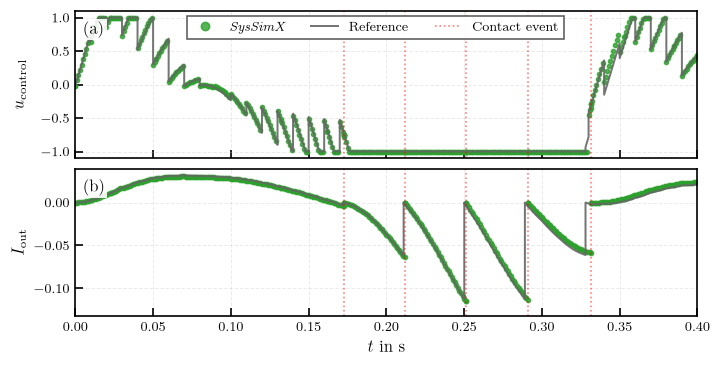

In [25]:
fig, (ax_u, ax_i) = plt.subplots(
    2, 1, sharex=True,
    figsize=(FULL_WIDTH, 0.5 * FULL_WIDTH),
    constrained_layout=True,
)

ref_style = dict(linestyle="-", color="0.4", linewidth=1.2, alpha=0.9)
cs_style  = dict(linestyle="None", marker="o", markersize=2.5, alpha=0.8,
                 color=palette["fmu"])

# (a) controller output command
ax_u.plot(t_pid, u_pid, **cs_style, label=r"\textit{SysSimX}")
ax_u.plot(ref_sol_reset["time"], ref_sol_reset["u_control"], **ref_style, label="Reference")


# (b) integrator state
ax_i.plot(t_pid, i_out, **cs_style)
ax_i.plot(ref_sol_reset["time"], ref_sol_reset["pid.I_out"], **ref_style)


# contact events on both panels, labelled once
for ax in (ax_u, ax_i):
    for k, t_event in enumerate(event_times_float):
        ax.axvline(
            t_event, color="red", linestyle=":", linewidth=1, alpha=0.5,
            label="Contact event" if (ax is ax_u and k == 0) else None,
        )

for ax in (ax_u, ax_i):
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_end)

ax_u.set_ylabel(r"$u_{\mathrm{control}}$")
ax_i.set_ylabel(r"$I_{\mathrm{out}}$")
ax_i.set_xlabel(r"$t$ in $\mathrm{s}$")

for label, ax in [("(a)", ax_u), ("(b)", ax_i)]:
    ax.text(
        0.012, 0.93, label, transform=ax.transAxes,
        ha="left", va="top", fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1.5),
    )

fig.align_ylabels((ax_u, ax_i))

handles, labels = ax_u.get_legend_handles_labels()
fig.legend(handles, labels, ncol=3,
           fontsize=8, markerscale=2, frameon=True, loc="upper center", bbox_to_anchor=(0.52, 0.99))

out = _repo / "notebooks" / "figures"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "05_b_multi_model_controller.pdf")
plt.show()


---

# Unified Event-Localized Region Switching

`MultiComponent` uses one ordered region map to decide when the active model changes.

The scalar key is `abs(theta)`, with FEM, OpenSim, and FMU assigned to increasing-angle regions.
Each boundary is localized by the hybrid algorithm independently of the communication grid.

`set_switch_regions()` generates each condition as a bidirectional zero-crossing named
`region_boundary_i`, armed at the far edge of its hysteresis band. The hybrid algorithm detects the
crossing, narrows it by bisection, and applies the switch at the located instant, which is the same
machinery that localizes the `wall_hit` contact event. Those generated events appear in the system
event history, so the placement of every region change is measured rather than inferred.

The run above uses the default three-model region policy. This section compares two macro-step sizes
against the **OpenModelica reference** rather than against another SysSimX mechanism,
using the event-time metric already defined above, and reports where each localized transition landed
relative to its own communication grid.

### Why the comparison covers all three models

The region map spans FEM, OpenSim, and FMU with each physical boundary represented once.
`MultiComponent` resolves the target from boundary identity and localized crossing direction,
so adjacent transitions remain deterministic even when one macro step crosses several boundaries.
Both comparison runs therefore exercise the same three-model policy; only the macro-step size differs.

### No time gate is required

Initialization needs no time gate: theta starts at 0, which is *inside* the FEM region. Initialization-time
reconciliation therefore establishes the FEM region before stepping, without recording a switch event,
and subsequent changes occur only at localized boundary crossings.


In [26]:
# The region policy is owned by MasterPendulumSwitchConfig. Read it back from
# the configured wrapper instead of restating the numbers, so a figure or a
# tolerance can never drift from the policy the run actually used.
SWITCH_BREAKPOINTS = tuple(pendulum.switch_regions.breakpoints)
SWITCH_BANDS = tuple(pendulum.switch_regions.bands)

# Both comparison runs use the tolerances of the main run above. That is not
# incidental - the two event families in this system want opposite things from
# `tol_time`, and this value is the one that serves both:
#
#   contact  `FEMPendulum` brackets the wall hit to its own sub-step (1e-4 s).
#            `_locate_event_time` would accept that bracket directly if
#            tol_time >= 1e-4, skipping bisection. Here it does not, so contact
#            costs ~4 extra FEM solves per event. Acceptable for one accuracy run.
#
#   switch   bisection resolves the crossing to tol_time. At 1.5e-4 that is 15 %
#            of a macro step, too coarse for useful localized placement, which defeats
#            the comparison. At 1e-5 it is 1 %.
#
# `tol_value` follows from `tol_time`: the generated region boundary is in radians and
# moves at |omega| ~ 2.5 rad/s, so bisecting to 1e-5 s leaves a residual near
# 2.5e-5 rad. Event acceptance uses the final sign-change bracket rather
# than requiring the endpoint value to fall inside this tolerance.
SWITCH_TOL_TIME = 1e-5
SWITCH_TOL_VALUE = 5e-5

print(f"region breakpoints in rad : {SWITCH_BREAKPOINTS}")
print(f"hysteresis bands in rad   : {SWITCH_BANDS}")
print(f"region modes              : {pendulum.switch_config.modes}")


def make_fem_parameters():
    sim = config.SimulationParameters()
    sim.tau = 0.001
    sim.t_end = t_end
    sim.with_contact = True
    sim.use_gravity = True

    anim = config.AnimationParameters()
    anim.animate = False
    return {"sim_params": sim, "anim_params": anim}


def build_region_system(label):
    """Closed loop using the default three-model angle-region policy."""
    plant = MasterPendulum(name="MasterPendulum", initial_mode="FMU")
    plant.set_parameters(**{"FEM": make_fem_parameters()})

    plant.initialize(t0=0.0)
    plant.add_event_indicator("wall_hit", func=wall_contact_indicator, direction=-1)
    sp = FMUComponent(name="Setpoint", fmu_path=fmu_paths["Trajectories"]["SetPoint"],
                      group="Reference")
    ctrl = PIDController(name="PID")
    drv = FMUComponent(name="Drive", fmu_path=fmu_paths["Actuators"]["DriveDynamic"],
                       group="Actuator")
    sens = FMUComponent(name="Angle Sensor", fmu_path=fmu_paths["Sensors"]["AngleSensor"],
                        group="Sensors")
    dec = FMUComponent(name="Angle Decoder", fmu_path=fmu_paths["Sensors"]["AngleDecoder"],
                       group="Signal Processing")

    system = System(name=f"Region switching ({label})")
    for comp in (sp, ctrl, drv, plant, dec, sens):
        system.add_component(comp)
    for conn in (
        Connection("Setpoint", "theta_ref", "PID", "theta_ref"),
        Connection("MasterPendulum", "theta", "Angle Sensor", "theta"),
        Connection("Angle Sensor", "v_out", "Angle Decoder", "v_in"),
        Connection("Angle Decoder", "theta", "PID", "theta_meas"),
        Connection("PID", "u", "Drive", "u_control"),
        Connection("Drive", "torque", "MasterPendulum", "tau"),
        Connection("MasterPendulum", "omega", "Drive", "omega"),
    ):
        system.add_connection(conn)
    system.add_event_connection(
        EventConnection("MasterPendulum", "wall_hit", "MasterPendulum", "omega_invert"))
    system.add_event_connection(
        EventConnection("MasterPendulum", "wall_hit", "PID", "resetI"))

    system.initialize(t0=0.0)
    # Same recording and tolerance settings as the main run, so the trajectories
    # below hold accepted communication points only.
    system.algorithm.record_internal_steps = False
    system.algorithm.event_dedup_tol = 5e-4
    system.algorithm.tol_time = SWITCH_TOL_TIME
    system.algorithm.tol_value = SWITCH_TOL_VALUE
    return system, plant


region breakpoints in rad : (0.075, 0.2617993877991494)
hysteresis bands in rad   : (0.005, 0.017453292519943295)
region modes              : ('FEM', 'OpenSim', 'FMU')


In [27]:
switch_runs = {}

for variant, macro_dt in (("fine", sim_params.tau), ("coarse", 4 * sim_params.tau)):
    sys_cmp, plant_cmp = build_region_system(variant)
    # Read the reconciled mode back, exactly as for the main run.
    initial_mode_cmp = plant_cmp.active_mode
    sys_cmp.run(0.0, t_end, macro_dt)

    hist = sys_cmp.get_history()
    t_cmp, data_cmp = hist["MasterPendulum"]
    contact_times = [d.t for d in hist["Events"][("MasterPendulum", "wall_hit")]]

    boundary_times = {}
    for (_comp, event_name), records in hist["Events"].items():
        if event_name.startswith("region_boundary_"):
            boundary_times.setdefault(event_name, []).extend(float(d.t) for d in records)

    intervals = build_mode_intervals(plant_cmp.sync_events, initial_mode_cmp, 0.0, t_end)

    switch_runs[variant] = {
        "dt": macro_dt,
        "t": np.asarray(t_cmp, dtype=float),
        "theta": np.asarray(data_cmp["theta"], dtype=float),
        "switch_times": [float(e["time"]) for e in plant_cmp.sync_events],
        "switch_modes": [f"{e['from_mode']}->{e['to_mode']}" for e in plant_cmp.sync_events],
        "contact_times": contact_times,
        "boundary_times": boundary_times,
        "mode_intervals": intervals,
        "fem_active_s": sum(b - a for a, b, m in intervals if m == "FEM"),
    }

    print(f"{variant:>10}: starts in {initial_mode_cmp}, "
          f"{len(plant_cmp.sync_events)} switches, "
          f"{len(contact_times)} contact events, "
          f"FEM active {switch_runs[variant]['fem_active_s']:.3f} s")

# The comparison is only valid if both runs resolve the same contact sequence,
# and it is only comparable to the reference if that sequence matches Modelica.
n_contacts = {s: len(r["contact_times"]) for s, r in switch_runs.items()}
n_contacts["reference"] = len(event_times_ref)
if len(set(n_contacts.values())) > 1:
    print(f"\nWARNING: contact counts differ {n_contacts}. The trajectories have diverged "
          f"into different bounce sequences, so the error columns below compare different "
          f"physics, not switch placement. Investigate before reading the table.")


      fine: starts in FEM, 6 switches, 4 contact events, FEM active 0.214 s
    coarse: starts in FEM, 12 switches, 5 contact events, FEM active 0.118 s



In [28]:
# --- Accuracy against the OpenModelica reference -----------------------
rows = []
for strategy, run in switch_runs.items():
    for interval, bounds in (("full horizon", (None, None)),
                             ("contact window", contact_window)):
        m = trajectory_error_metrics(
            run["t"], run["theta"],
            ref_sol_reset["time"], ref_sol_reset["theta"],
            t_min=bounds[0], t_max=bounds[1],
        )
        rows.append({"switching": strategy, "interval": interval,
                     "E_inf": m["e_inf"], "E_2": m["e_2"], "E_mean": m["e_mean"]})

    ev = event_time_metrics(run["contact_times"], event_times_ref)
    rows.append({"switching": strategy, "interval": "contact event times",
                 "E_inf": ev["max_abs_delta"], "E_2": np.nan, "E_mean": ev["mean_abs_delta"]})

df_switch_cmp = pd.DataFrame(rows)
display(
    df_switch_cmp.style
    .format({"E_inf": "{:.3e}", "E_2": "{:.3e}", "E_mean": "{:.3e}"}, na_rep="-")
    .hide(axis="index")
)

# --- Where the transitions landed --------------------------------------
placement = pd.DataFrame({
    "fine_t": pd.Series(switch_runs["fine"]["switch_times"]),
    "fine_mode": pd.Series(switch_runs["fine"]["switch_modes"]),
    "coarse_t": pd.Series(switch_runs["coarse"]["switch_times"]),
    "coarse_mode": pd.Series(switch_runs["coarse"]["switch_modes"]),
})
placement["shift_s"] = placement["coarse_t"] - placement["fine_t"]

print("\nswitch instants")
print(placement.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# --- Placement relative to each communication grid ----------------------
# A transition that only ever landed on a communication point would show an
# off-grid distance of zero and the localization claim would be empty.
grid_rows = []
for strategy, run in switch_runs.items():
    for event_name, times in sorted(run["boundary_times"].items()):
        for t_event in times:
            grid_rows.append({
                "switching": strategy,
                "dt": run["dt"],
                "boundary": event_name,
                "t": t_event,
                "off_grid": _distance_to_grid(t_event, run["dt"]),
                "off_grid_rel": _distance_to_grid(t_event, run["dt"]) / run["dt"],
            })

df_grid = pd.DataFrame(grid_rows)
if df_grid.empty:
    print("\nNo region boundary crossings were localized in either run.")
else:
    print("\nboundary placement relative to the communication grid")
    display(
        df_grid.style
        .format({"dt": "{:.3e}", "t": "{:.6f}", "off_grid": "{:.3e}", "off_grid_rel": "{:.3f}"})
        .hide(axis="index")
    )

print(f"\nFEM active   fine {switch_runs['fine']['fem_active_s']:.3f} s"
      f"   coarse {switch_runs['coarse']['fem_active_s']:.3f} s")
print("Localized switch placement should remain stable as the macro step changes.")


switching,interval,E_inf,E_2,E_mean
fine,full horizon,2.607e-02,6.504e-03,4.212e-03
fine,contact window,2.607e-02,9.034e-03,7.005e-03
fine,contact event times,4.281e-02,-,3.119e-02
coarse,full horizon,9.797e-02,3.691e-02,2.524e-02
coarse,contact window,9.797e-02,5.156e-02,3.888e-02
coarse,contact event times,3.789e-02,-,1.590e-02



switch instants
  fine_t    fine_mode  coarse_t  coarse_mode   shift_s
0.023250 FEM->OpenSim  0.025688 FEM->OpenSim  0.002437
0.051844 OpenSim->FMU  0.053844 OpenSim->FMU  0.002000
0.132469 FMU->OpenSim  0.134516 FMU->OpenSim  0.002047
0.162047 OpenSim->FEM  0.162305 OpenSim->FEM  0.000258
0.353016 FEM->OpenSim  0.184641 FEM->OpenSim -0.168375
0.384805 OpenSim->FMU  0.218953 OpenSim->FEM -0.165852
     NaN          NaN  0.242234 FEM->OpenSim       NaN
     NaN          NaN  0.265711 OpenSim->FEM       NaN
     NaN          NaN  0.287273 FEM->OpenSim       NaN
     NaN          NaN  0.324828 OpenSim->FEM       NaN
     NaN          NaN  0.350391 FEM->OpenSim       NaN
     NaN          NaN  0.387398 OpenSim->FMU       NaN

boundary placement relative to the communication grid


switching,dt,boundary,t,off_grid,off_grid_rel
fine,1.000e-03,region_boundary_0,0.023250,2.500e-04,0.250
fine,1.000e-03,region_boundary_0,0.162047,4.688e-05,0.047
fine,1.000e-03,region_boundary_0,0.353016,1.563e-05,0.016
fine,1.000e-03,region_boundary_1,0.051844,1.562e-04,0.156
fine,1.000e-03,region_boundary_1,0.132469,4.688e-04,0.469
fine,1.000e-03,region_boundary_1,0.384805,1.953e-04,0.195
coarse,4.000e-03,region_boundary_0,0.025688,1.688e-03,0.422
coarse,4.000e-03,region_boundary_0,0.162305,1.695e-03,0.424
coarse,4.000e-03,region_boundary_0,0.184641,6.406e-04,0.160
coarse,4.000e-03,region_boundary_0,0.218953,1.047e-03,0.262



FEM active   fine 0.214 s   coarse 0.118 s
Localized switch placement should remain stable as the macro step changes.


### Trajectory comparison

Panel (a) shows the whole horizon with the mode strips underneath: the upper strip is the
fine-step run, the lower one the coarse-step run. Both strips use one colour per model, so a
three-model policy remains readable as three bands. Panel (b) zooms on the contact window, where
the two runs should place their localized transitions consistently and where the deviation from the
reference is largest. Panel (c) magnifies a single transition against the communication grid of the
fine run, so the placement difference is visible at all.


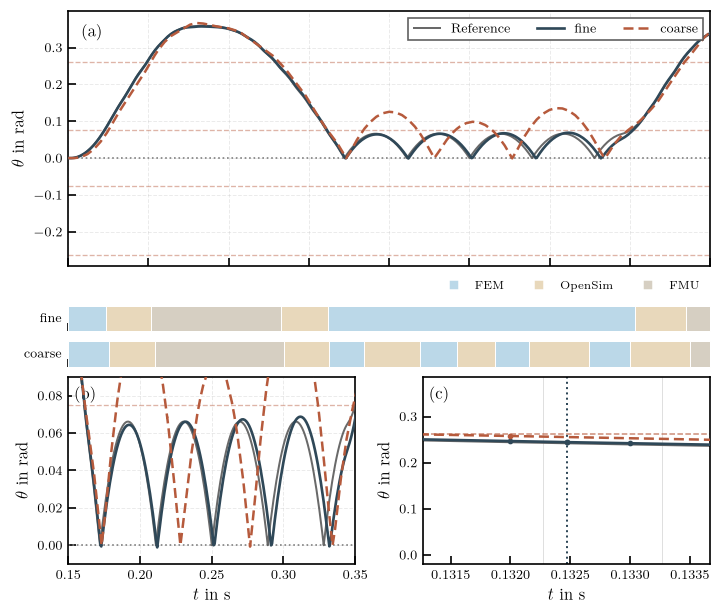

In [29]:
STRATEGY_STYLE = {
    "fine":   dict(color="#2F4858", linewidth=1.6, linestyle="-",          zorder=4),
    "coarse": dict(color="#B65A3C", linewidth=1.5, linestyle=(0, (4, 2)), zorder=5),
}
# One entry per region model: a missing mode would render as unlabelled grey and
# hide a whole region of the policy.
MODE_STRIP = {"FEM": "#bbd8e8", "OpenSim": "#e8d8bb", "FMU": "#d6cfc2"}

fig = plt.figure(figsize=(FULL_WIDTH, 0.85 * FULL_WIDTH), constrained_layout=True)
gs = fig.add_gridspec(4, 2, height_ratios=[3.0, 0.30, 0.30, 2.2])

ax_full = fig.add_subplot(gs[0, :])
ax_strip_fine = fig.add_subplot(gs[1, :], sharex=ax_full)
ax_strip_coarse = fig.add_subplot(gs[2, :], sharex=ax_full)
ax_contact = fig.add_subplot(gs[3, 0])
ax_zoom = fig.add_subplot(gs[3, 1])

# --- (a) full horizon, (b) contact window ------------------------------
for ax in (ax_full, ax_contact):
    ax.plot(ref_sol_reset["time"], ref_sol_reset["theta"],
            color="0.35", linewidth=1.2, alpha=0.9, label="Reference", zorder=3)
    for strategy, run in switch_runs.items():
        ax.plot(run["t"], run["theta"], label=strategy, **STRATEGY_STYLE[strategy])
    ax.axhline(0, color="gray", linestyle=":", linewidth=1)
    # Every configured breakpoint, not only the first one.
    for threshold in SWITCH_BREAKPOINTS:
        for sign in (+1, -1):
            ax.axhline(sign * threshold, color="#B65A3C",
                       linestyle="--", linewidth=0.8, alpha=0.45)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel(r"$\theta$ in $\mathrm{rad}$")

ax_full.set_xlim(0, t_end)
ax_full.tick_params(labelbottom=False)
ax_full.legend(loc="upper right", ncol=3, fontsize=8, frameon=True)

# --- mode strips, one per strategy -------------------------------------
for ax, strategy in ((ax_strip_fine, "fine"), (ax_strip_coarse, "coarse")):
    for a, b, mode in switch_runs[strategy]["mode_intervals"]:
        if b <= a:
            continue
        ax.broken_barh([(a, b - a)], (0, 1), facecolors=MODE_STRIP[mode],
                       edgecolors="white", linewidth=0.6)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlim(0, t_end)
    ax.set_ylabel(strategy, rotation=0, ha="right", va="center", fontsize=8)
    ax.grid(False)
    for spine in ("left", "right", "top", "bottom"):
        ax.spines[spine].set_visible(False)
ax_strip_fine.tick_params(labelbottom=False)
ax_strip_coarse.tick_params(labelbottom=False)

mode_handles = [
    plt.Line2D([], [], marker="s", linestyle="None", markersize=6,
               markerfacecolor=color, markeredgecolor="white", label=mode)
    for mode, color in MODE_STRIP.items()
]
ax_strip_fine.legend(handles=mode_handles, loc="upper right", ncol=3, fontsize=7,
                     frameon=False, bbox_to_anchor=(1.0, 2.4))

# --- (b) contact-window zoom -------------------------------------------
ax_contact.set_xlim(*contact_window)
ax_contact.set_ylim(-0.01, 0.09)
ax_contact.set_xlabel(r"$t$ in $\mathrm{s}$")

# --- (c) single-transition zoom ----------------------------------------
# Centre on whichever transition localization moved furthest off the
# communication grid, and span only ~2 macro steps: at a wider span a
# sub-millisecond offset is a few pixels and the panel shows nothing.
_fine = switch_runs["fine"]
_loc_switches = _fine["switch_times"]
_idx = int(np.argmax([_distance_to_grid(t, _fine["dt"]) for t in _loc_switches]))
t_focus = _loc_switches[_idx]
span = 1.2 * _fine["dt"]

# The boundary this transition crossed, taken from the trajectory rather than
# assumed to be the first breakpoint.
theta_focus = abs(float(np.interp(t_focus, _fine["t"], _fine["theta"])))
threshold_focus = min(SWITCH_BREAKPOINTS, key=lambda b: abs(b - theta_focus))

ax_zoom.plot(ref_sol_reset["time"], ref_sol_reset["theta"],
             color="0.35", linewidth=1.2, alpha=0.9)
for strategy, run in switch_runs.items():
    ax_zoom.plot(run["t"], run["theta"], marker="o", markersize=2.5,
                 **STRATEGY_STYLE[strategy])
    for t_sw in run["switch_times"]:
        if abs(t_sw - t_focus) < span:
            ax_zoom.axvline(t_sw, color=STRATEGY_STYLE[strategy]["color"],
                            linestyle=":", linewidth=1.2)
ax_zoom.axhline(threshold_focus, color="#B65A3C", linestyle="--",
                linewidth=0.9, alpha=0.7)
for t_grid in np.arange(t_focus - span, t_focus + span, _fine["dt"]):
    ax_zoom.axvline(t_grid, color="0.85", linewidth=0.5, zorder=0)
ax_zoom.set_xlim(t_focus - span, t_focus + span)
ax_zoom.set_xlabel(r"$t$ in $\mathrm{s}$")
ax_zoom.set_ylabel(r"$\theta$ in $\mathrm{rad}$")
ax_zoom.grid(False)

for label, ax in [("(a)", ax_full), ("(b)", ax_contact), ("(c)", ax_zoom)]:
    ax.text(0.02, 0.95, label, transform=ax.transAxes, ha="left", va="top",
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1.5))

out = _repo / "notebooks" / "figures"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "05_c_switching_strategy.pdf")
plt.show()
